# Questão 01: Implementação do Algoritmo Perceptron (Manual)

Este notebook implementa o algoritmo Perceptron do zero para resolver as funções lógicas AND, OR e XOR, com visualização do hiperplano durante o treinamento para 2 entradas.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import time
from mpl_toolkits.mplot3d import Axes3D # Para plotagem 3D
from sklearn.decomposition import PCA   # Para PCA

# Para plotagem interativa/animada no Jupyter Notebook / VS Code, 
# %matplotlib notebook ou %matplotlib ipympl podem ser úteis.
# %matplotlib notebook

## Funções Auxiliares (Geração de Dados e Plotagem)

In [19]:
def gerar_dados(n_entradas, tipo_funcao='AND'):
    # ... (código da função gerar_dados permanece o MESMO da última versão) ...
    X = np.array(list(product([0, 1], repeat=n_entradas)))
    if tipo_funcao.upper() == 'AND':
        y = np.array([int(np.all(x_i)) for x_i in X])
    elif tipo_funcao.upper() == 'OR':
        y = np.array([int(np.any(x_i)) for x_i in X])
    elif tipo_funcao.upper() == 'XOR':
        if n_entradas != 2:
             print("Atenção: XOR para n!=2 é definido como paridade (soma das entradas % 2 == 1).")
        y = np.array([np.sum(x_i) % 2 for x_i in X]) 
    else:
        raise ValueError("Função lógica inválida. Use 'AND', 'OR' ou 'XOR'.")
    return X, y

def plotar_hiperplano_2d(X, y, perceptron_model, ax, titulo_plot):
    # ... (código da função plotar_hiperplano_2d permanece o MESMO da última versão) ...
    ax.clear()
    cores = ['blue', 'red']
    marcadores = ['o', 'x']
    if not hasattr(plotar_hiperplano_2d, "_legend_info"):
        plotar_hiperplano_2d._legend_info = {'class0_added': False, 'class1_added': False}
    if not ax.collections and not ax.lines: 
        plotar_hiperplano_2d._legend_info['class0_added'] = False
        plotar_hiperplano_2d._legend_info['class1_added'] = False
    for i in range(len(X)):
        current_label = None 
        if y[i] == 0 and not plotar_hiperplano_2d._legend_info['class0_added']:
            current_label = 'Classe 0'
            plotar_hiperplano_2d._legend_info['class0_added'] = True
        elif y[i] == 1 and not plotar_hiperplano_2d._legend_info['class1_added']:
            current_label = 'Classe 1'
            plotar_hiperplano_2d._legend_info['class1_added'] = True
        ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)
    w = perceptron_model.pesos
    if w is not None and len(w) == 3: 
        x_data_min_plot, x_data_max_plot = -0.5, 1.5 
        y_data_min_plot, y_data_max_plot = -0.5, 1.5
        line_x_coords = np.array([x_data_min_plot, x_data_max_plot])
        if abs(w[2]) > 1e-5: 
            line_y_coords = (-w[1] * line_x_coords - w[0]) / w[2]
            ax.plot(line_x_coords, line_y_coords, '--', color='green', linewidth=2)
        elif abs(w[1]) > 1e-5: 
            x_vert_coord = -w[0] / w[1]
            ax.plot([x_vert_coord, x_vert_coord], [y_data_min_plot, y_data_max_plot], '--', color='green', linewidth=2)
    ax.set_title(titulo_plot, fontsize=14)
    ax.set_xlabel("Entrada x1", fontsize=12)
    ax.set_ylabel("Entrada x2", fontsize=12)
    ax.set_xlim([x_data_min_plot, x_data_max_plot])
    ax.set_ylim([y_data_min_plot, y_data_max_plot])
    ax.grid(True, linestyle=':', alpha=0.7)
    handles, labels = ax.get_legend_handles_labels()
    if any(labels): 
        ax.legend(loc='best', fontsize=10)
    if hasattr(ax.figure, 'canvas') and ax.figure.canvas is not None:
        ax.figure.canvas.draw_idle()
    time.sleep(0.1) 

def plotar_curva_erro(erros_por_epoca, titulo_plot):
    # ... (código da função plotar_curva_erro permanece o MESMO da última versão) ...
    fig_erro, ax_erro = plt.subplots(figsize=(7,5)) 
    ax_erro.plot(range(1, len(erros_por_epoca) + 1), erros_por_epoca, marker='o', linestyle='-', color='purple')
    ax_erro.set_xlabel('Época', fontsize=12)
    ax_erro.set_ylabel('Número de Erros de Classificação', fontsize=12)
    ax_erro.set_title(titulo_plot, fontsize=14)
    ax_erro.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# NOVA FUNÇÃO
def plotar_hiperplano_3d_final(X, y, perceptron_model, titulo_plot):
    """
    Plota os dados e o hiperplano de separação 3D (final) para n=3 entradas.
    """
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    cores = ['blue', 'red']
    marcadores = ['o', 'x']

    for i in range(len(X)):
        ax.scatter(X[i, 0], X[i, 1], X[i, 2], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=f'Classe {y[i]}' if i < 2 else "")

    w = perceptron_model.pesos # w0, w1, w2, w3
    if w is not None and len(w) == 4:
        # Criar um grid para x1 e x2
        # Limites baseados nos dados para melhor visualização do plano
        x1_range = np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 10)
        x2_range = np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 10)
        xx1, xx2 = np.meshgrid(x1_range, x2_range)

        # Calcular x3 correspondente: w0 + w1*x1 + w2*x2 + w3*x3 = 0
        # x3 = (-w1*x1 - w2*x2 - w0) / w3
        if abs(w[3]) > 1e-5: # Se w3 não for zero
            xx3 = (-w[1] * xx1 - w[2] * xx2 - w[0]) / w[3]
            ax.plot_surface(xx1, xx2, xx3, alpha=0.3, color='green', rstride=100, cstride=100, edgecolor='none')
        elif abs(w[2]) > 1e-5: # Se w3 é zero, mas w2 não é (plano vertical em relação a x3)
             # w0 + w1*x1 + w2*x2 = 0 => x2 = (-w1*x1 - w0) / w2
             # O plano é constante ao longo do eixo x3
            xx3_dummy_min, xx3_dummy_max = X[:,2].min()-0.1, X[:,2].max()+0.1 # Extensão para x3
            yy = (-w[1]*xx1 - w[0]) / w[2] # Valores de x2
            # Para plotar uma superfície vertical, precisamos de uma forma diferente
            # Vamos plotar duas linhas de contorno e preencher entre elas visualmente se possível
            # Ou simplesmente plotar a "sombra" do plano nos limites do eixo x3
            # Para simplificar: plotar o plano como se fosse uma parede
            X_surf = np.array([xx1.ravel(), yy.ravel()]).T # Coordenadas (x1,x2) do plano
            # Criar uma malha para o plano vertical
            # Definimos x1 e x3, calculamos x2
            x1_surf_range = np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 2)
            x3_surf_range = np.linspace(X[:,2].min()-0.1, X[:,2].max()+0.1, 2)
            x1_surf, x3_surf = np.meshgrid(x1_surf_range, x3_surf_range)
            x2_surf = (-w[1] * x1_surf - w[0]) / w[2]
            ax.plot_surface(x1_surf, x2_surf, x3_surf, alpha=0.3, color='green', edgecolor='none')

        # Outros casos (w1 não zero, ou apenas w0 não zero) podem ser mais complexos de visualizar como superfície única
        # e indicariam planos alinhados com os eixos.

    ax.set_xlabel('Entrada x1', fontsize=12)
    ax.set_ylabel('Entrada x2', fontsize=12)
    ax.set_zlabel('Entrada x3', fontsize=12)
    ax.set_title(titulo_plot, fontsize=14)
    
    # Adicionar legenda se não estiver muito poluído
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        # Para evitar duplicatas na legenda 3D, uma abordagem mais simples:
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], marker='o', color='w', label='Classe 0', markerfacecolor='blue', markersize=10),
                           Line2D([0], [0], marker='x', color='w', label='Classe 1', markerfacecolor='red', markersize=10)]
        ax.legend(handles=legend_elements, loc='best')

    plt.show()

# NOVA FUNÇÃO
def plotar_pca_2d_final(X, y, titulo_plot):
    """
    Aplica PCA para reduzir X a 2D e plota os pontos projetados.
    """
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(7, 6))
    cores = ['blue', 'red']
    marcadores = ['o', 'x']
    
    # Legenda única
    label_classe0_added = False
    label_classe1_added = False

    for i in range(len(X_pca)):
        label_atual = ""
        if y[i] == 0 and not label_classe0_added:
            label_atual = 'Classe 0'
            label_classe0_added = True
        elif y[i] == 1 and not label_classe1_added:
            label_atual = 'Classe 1'
            label_classe1_added = True
        ax.scatter(X_pca[i, 0], X_pca[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=label_atual)

    ax.set_xlabel('Primeiro Componente Principal (PC1)', fontsize=12)
    ax.set_ylabel('Segundo Componente Principal (PC2)', fontsize=12)
    ax.set_title(titulo_plot, fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.7)
    if label_classe0_added or label_classe1_added:
        ax.legend(loc='best', fontsize=10)
    plt.show()

## Classe Perceptron

In [20]:
class Perceptron:
    def __init__(self, taxa_aprendizado=0.1, n_epocas=100):
        # ... (código interno da classe Perceptron como antes) ...
        self.taxa_aprendizado = taxa_aprendizado
        self.n_epocas = n_epocas
        self.pesos = None
        self.erros_por_epoca = []

    def _adicionar_bias_input(self, X_i):
        return np.insert(X_i, 0, 1)

    def predict(self, X_i_com_bias):
        z = np.dot(X_i_com_bias, self.pesos)
        return 1 if z >= 0 else 0

    def fit(self, X, y, ax_plot=None, X_original_plot=None, y_original_plot=None, plot_interval=1, title_suffix=""):
        n_amostras, n_caracteristicas = X.shape
        self.pesos = np.random.rand(n_caracteristicas + 1) * 0.1 - 0.05
        self.erros_por_epoca = []
        X_com_bias = np.insert(X, 0, 1, axis=1)
        convergiu = False
        for epoca in range(self.n_epocas):
            erros_epoca_atual = 0
            for i in range(n_amostras):
                X_i_com_bias = X_com_bias[i]
                y_i_real = y[i]
                y_predito = self.predict(X_i_com_bias)
                erro = y_i_real - y_predito
                if erro != 0:
                    erros_epoca_atual += 1
                    self.pesos += self.taxa_aprendizado * erro * X_i_com_bias
            self.erros_por_epoca.append(erros_epoca_atual)
            if ax_plot and X_original_plot is not None and y_original_plot is not None:
                if (epoca + 1) % plot_interval == 0 or (erros_epoca_atual == 0 and epoca > 0):
                    plotar_hiperplano_2d(X_original_plot, y_original_plot, self, ax_plot, f"Época: {epoca + 1}{title_suffix}") 
                    if erros_epoca_atual == 0 and epoca > 0: 
                        print(f"Convergência alcançada na época {epoca + 1}.")
                        convergiu = True
                        break 
            if erros_epoca_atual == 0 and epoca > 0: 
                if not ax_plot: 
                     print(f"Convergência alcançada na época {epoca + 1}.")
                convergiu = True
                break
        if convergiu and ax_plot and X_original_plot is not None and y_original_plot is not None and self.erros_por_epoca[-1] == 0: 
            plotar_hiperplano_2d(X_original_plot, y_original_plot, self, ax_plot, f"Convergência Final - Época: {len(self.erros_por_epoca)}{title_suffix}")
        elif not convergiu and len(self.erros_por_epoca) > 0 and self.erros_por_epoca[-1] !=0 : # Adicionado len > 0
            print(f"Não convergiu após {len(self.erros_por_epoca)} épocas. Erros na última época: {self.erros_por_epoca[-1]}")

## Demonstração: Perceptron para XOR com 2 entradas

--- Demonstração: Perceptron para XOR com 2 entradas ---
Plotando hiperplano para XOR durante o treinamento (n=2)...


C:\Users\Luan\AppData\Local\Temp\ipykernel_8028\776257844.py:34: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)


Não convergiu após 50 épocas. Erros na última época: 4

Pesos finais para XOR: [ 0.07819056 -0.1182782   0.01342736]
Predições finais para XOR:
Entrada: [0 0], Saída Esperada: 0, Saída Predita: 1
Entrada: [0 1], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 0], Saída Esperada: 1, Saída Predita: 0
Entrada: [1 1], Saída Esperada: 0, Saída Predita: 0
Acurácia final para XOR: 50.00%


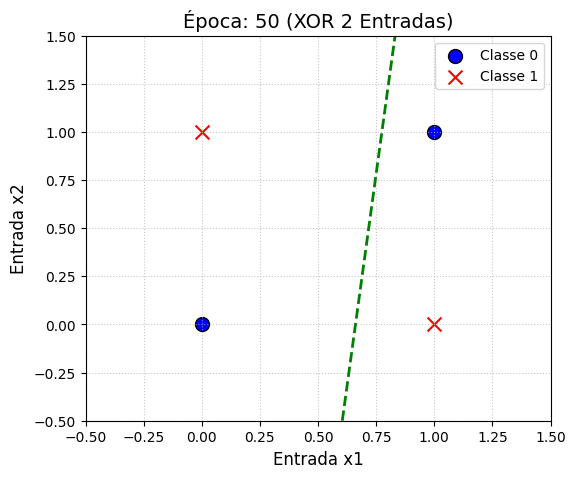

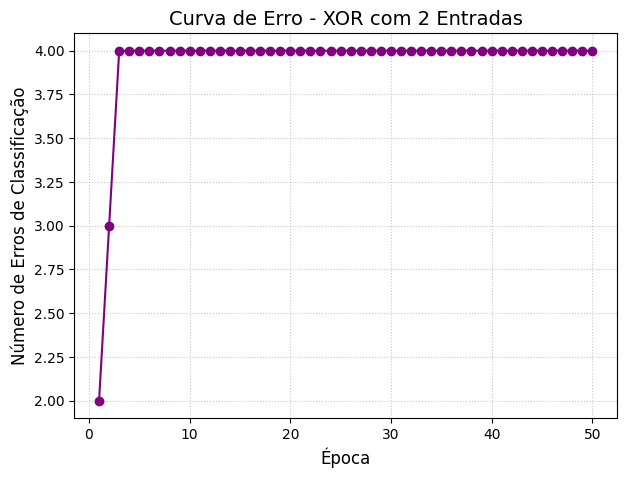


Observe a curva de erro do XOR e o hiperplano que não consegue separar as classes.


In [21]:
print("--- Demonstração: Perceptron para XOR com 2 entradas ---")
X_xor, y_xor = gerar_dados(n_entradas=2, tipo_funcao='XOR')
perceptron_xor = Perceptron(taxa_aprendizado=0.1, n_epocas=50)

fig_xor_anim, ax_xor_anim = plt.subplots(figsize=(6,5))
print("Plotando hiperplano para XOR durante o treinamento (n=2)...")

try:
    perceptron_xor.fit(X_xor, y_xor, ax_xor_anim, X_xor, y_xor, plot_interval=1, title_suffix=" (XOR 2 Entradas)")
    if fig_xor_anim.canvas: 
        fig_xor_anim.canvas.draw_idle()
        fig_xor_anim.canvas.flush_events()
except Exception as e:
    print(f"Erro durante a plotagem animada: {e}")

print("\nPesos finais para XOR:", perceptron_xor.pesos)
print("Predições finais para XOR:")
acertos_xor = 0
if len(X_xor) > 0:
    for i in range(len(X_xor)):
        entrada_com_bias = perceptron_xor._adicionar_bias_input(X_xor[i])
        predicao = perceptron_xor.predict(entrada_com_bias)
        if predicao == y_xor[i]:
            acertos_xor +=1
        print(f"Entrada: {X_xor[i]}, Saída Esperada: {y_xor[i]}, Saída Predita: {predicao}")
    print(f"Acurácia final para XOR: {acertos_xor/len(X_xor)*100:.2f}%")

plotar_curva_erro(perceptron_xor.erros_por_epoca, "Curva de Erro - XOR com 2 Entradas")
print("\nObserve a curva de erro do XOR e o hiperplano que não consegue separar as classes.")
plt.show()

## Função para Executar Testes com AND e OR

In [22]:
def executar_teste_perceptron(tipo_funcao, num_entradas, taxa_aprendizado=0.1, n_epocas=100, plot_interval_anim=1):
    """
    Executa um teste completo para o Perceptron com a função e número de entradas especificados.
    """
    print(f"\n--- Testando Perceptron para {tipo_funcao.upper()} com {num_entradas} entradas ---")
    
    X_teste, y_teste = gerar_dados(n_entradas=num_entradas, tipo_funcao=tipo_funcao.upper())
    perceptron_teste = Perceptron(taxa_aprendizado=taxa_aprendizado, n_epocas=n_epocas)
    
    ax_plot_teste = None 
    fig_anim_teste = None 

    if num_entradas == 2:
        print("Plotando hiperplano 2D animado durante o treinamento...")
        fig_anim_teste, ax_plot_teste = plt.subplots(figsize=(6,5)) 
        try:
            perceptron_teste.fit(X_teste, y_teste, ax_plot_teste, X_teste, y_teste, 
                                 plot_interval=plot_interval_anim, 
                                 title_suffix=f" ({tipo_funcao.upper()} {num_entradas} Entradas)")
            if fig_anim_teste and fig_anim_teste.canvas: 
                fig_anim_teste.canvas.draw_idle()
                fig_anim_teste.canvas.flush_events()
        except Exception as e:
            print(f"Erro durante a plotagem animada 2D: {e}")
    else:
        print(f"Treinando o Perceptron para n={num_entradas} entradas...")
        perceptron_teste.fit(X_teste, y_teste) # Sem plotagem animada do hiperplano

    # --- Impressão de Resultados ---
    print(f"\nPesos finais para {tipo_funcao.upper()} com {num_entradas} entradas:", perceptron_teste.pesos)
    print(f"Predições finais (amostra) para {tipo_funcao.upper()} com {num_entradas} entradas:")
    acertos_teste = 0
    amostras_a_mostrar_indices = []
    if len(X_teste) == 0:
        print("Nenhum dado gerado.")
    elif len(X_teste) <= 6:
        amostras_a_mostrar_indices = range(len(X_teste))
    else:
        amostras_a_mostrar_indices = list(range(3)) + list(range(len(X_teste) - 3, len(X_teste)))
    for i in amostras_a_mostrar_indices:
        if i < len(X_teste): 
            entrada_com_bias = perceptron_teste._adicionar_bias_input(X_teste[i])
            predicao = perceptron_teste.predict(entrada_com_bias)
            if predicao == y_teste[i]:
                acertos_teste +=1
            print(f"Entrada: {X_teste[i]}, Saída Esperada: {y_teste[i]}, Saída Predita: {predicao}")
    if len(X_teste) > 0: 
        print(f"Acurácia final: {acertos_teste/len(X_teste)*100:.2f}%")

    # --- Plotagens Finais ---
    plotar_curva_erro(perceptron_teste.erros_por_epoca, f"Curva de Erro - {tipo_funcao.upper()} com {num_entradas} Entradas")

    if num_entradas == 3 and perceptron_teste.erros_por_epoca[-1] == 0 : # Plotar 3D se convergiu
        print("Plotando hiperplano 3D final...")
        plotar_hiperplano_3d_final(X_teste, y_teste, perceptron_teste, 
                                   f"Hiperplano Final 3D - {tipo_funcao.upper()} {num_entradas} Entradas")
    elif num_entradas > 3:
        print("Plotando visualização PCA 2D dos dados finais...")
        plotar_pca_2d_final(X_teste, y_teste, 
                            f"Visualização PCA 2D - {tipo_funcao.upper()} {num_entradas} Entradas")
    
    if fig_anim_teste: # Se uma figura de animação foi criada
         plt.show() # Garante que a figura da animação seja exibida/mantida
    
    print(f"\nFim do teste para {tipo_funcao.upper()} com {num_entradas} entradas.")

## Executando Testes para AND e OR


--- Testando Perceptron para AND com 2 entradas ---
Plotando hiperplano 2D animado durante o treinamento...


C:\Users\Luan\AppData\Local\Temp\ipykernel_8028\776257844.py:34: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)


Convergência alcançada na época 9.

Pesos finais para AND com 2 entradas: [-0.34511604  0.2690784   0.16069846]
Predições finais (amostra) para AND com 2 entradas:
Entrada: [0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final: 100.00%


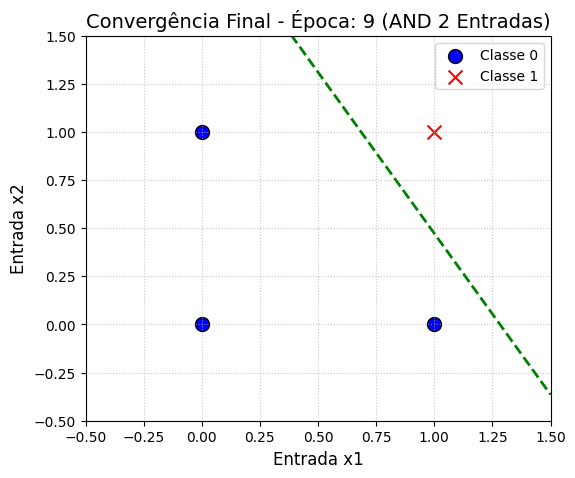

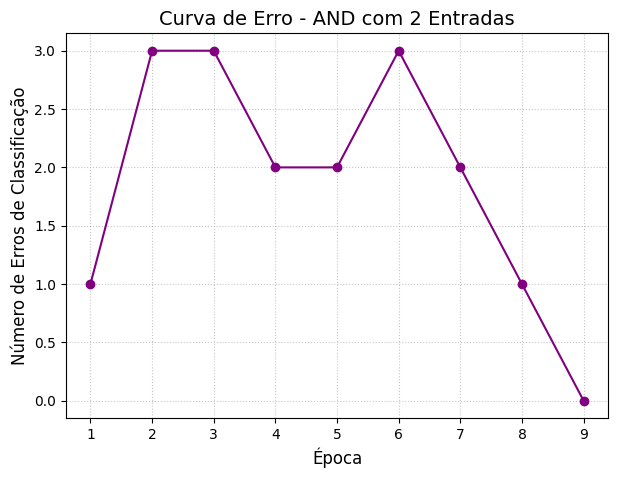


Fim do teste para AND com 2 entradas.


In [23]:
# Exemplo 1: AND com 2 entradas
# A animação do hiperplano será mostrada, seguida pela curva de erro.
# Aumentei n_epocas para dar mais tempo para a animação se necessário.
executar_teste_perceptron(tipo_funcao="AND", num_entradas=2, n_epocas=30, plot_interval_anim=1)


--- Testando Perceptron para OR com 3 entradas ---
Treinando o Perceptron para n=3 entradas...
Convergência alcançada na época 6.

Pesos finais para OR com 3 entradas: [-0.06584022  0.09292706  0.09000124  0.15700098]
Predições finais (amostra) para OR com 3 entradas:
Entrada: [0 0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 0 1], Saída Esperada: 1, Saída Predita: 1
Entrada: [0 1 0], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 0 1], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 1 0], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final: 75.00%


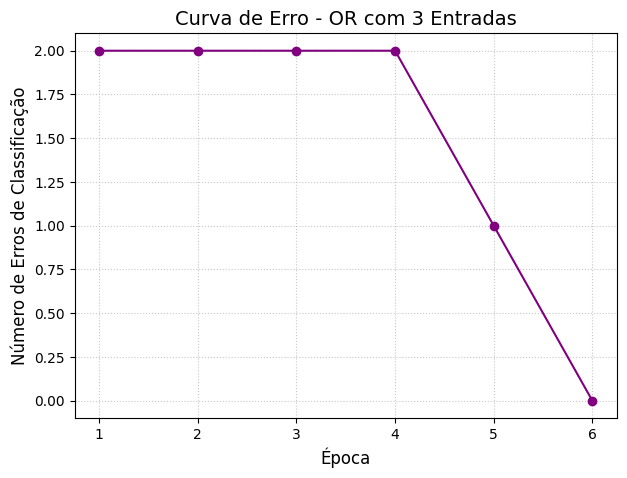

Plotando hiperplano 3D final...


C:\Users\Luan\AppData\Local\Temp\ipykernel_8028\776257844.py:81: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], X[i, 2], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=f'Classe {y[i]}' if i < 2 else "")


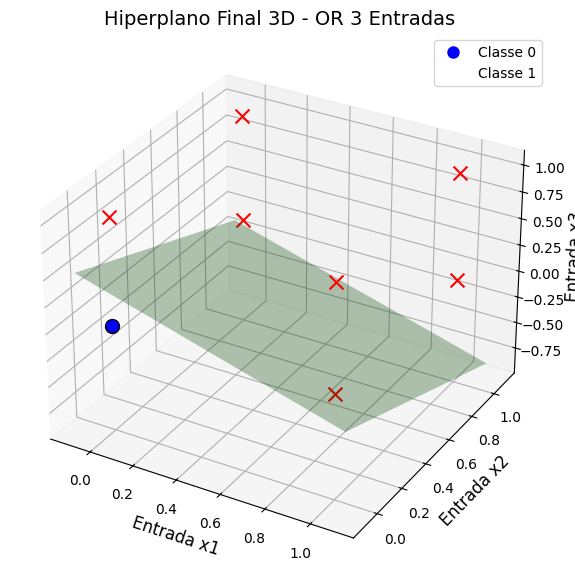


Fim do teste para OR com 3 entradas.


In [25]:
# Exemplo 2: OR com 2 entradas
# A animação do hiperplano será mostrada, seguida pela curva de erro.
executar_teste_perceptron(tipo_funcao="OR", num_entradas=3, n_epocas=50)


--- Testando Perceptron para AND com 4 entradas ---
Treinando o Perceptron para n=4 entradas...
Convergência alcançada na época 13.

Pesos finais para AND com 4 entradas: [-0.63001754  0.26214284  0.22489229  0.11471185  0.08851353]
Predições finais (amostra) para AND com 4 entradas:
Entrada: [0 0 0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 0 0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 0 1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1 0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1 1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1 1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final: 37.50%


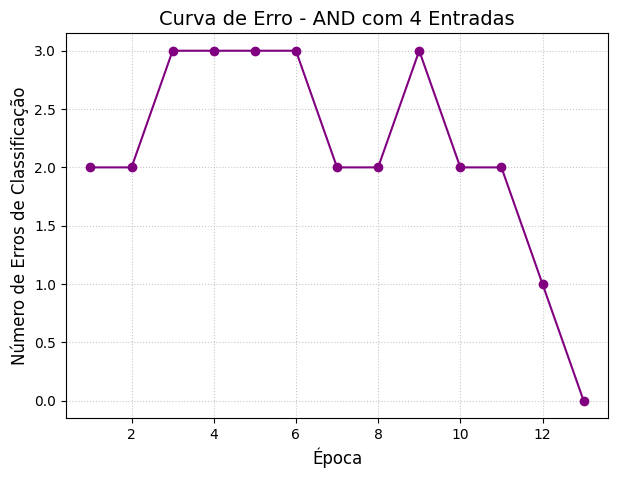

Plotando visualização PCA 2D dos dados finais...


C:\Users\Luan\AppData\Local\Temp\ipykernel_8028\776257844.py:157: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_pca[i, 0], X_pca[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=label_atual)


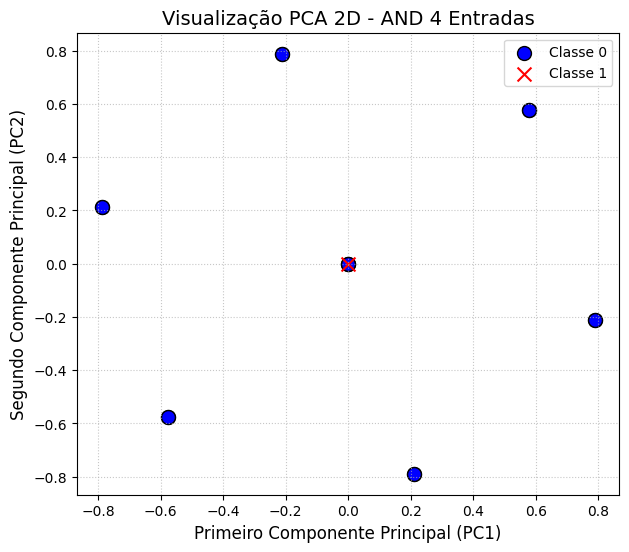


Fim do teste para AND com 4 entradas.


In [26]:
# Exemplo 3: AND com 3 entradas
# Não haverá animação do hiperplano, apenas a curva de erro será plotada.
executar_teste_perceptron(tipo_funcao="AND", num_entradas=4, n_epocas=100)